<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/main/02_Replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install Libraries, Download Data, and Build Dataset


In [6]:
# ==============================================================
# STEP 1: Install all required libraries
# ==============================================================
!pip install pandas numpy matplotlib seaborn statsmodels scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import urllib.request
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('Libraries loaded.')

# ==============================================================
# STEP 2: Download raw data directly from Card's Berkeley archive
# ==============================================================
print('Downloading Card & Krueger (1994) data...')
urllib.request.urlretrieve(
    'https://davidcard.berkeley.edu/data_sets/njmin.zip',
    'data/raw/njmin.zip'
)
with zipfile.ZipFile('data/raw/njmin.zip', 'r') as z:
    z.extractall('data/raw/')
print('Download and extraction complete.')
print('Files in data/raw/:', os.listdir('data/raw/'))

# ==============================================================
# STEP 3: Parse the whitespace-delimited file using codebook
# ==============================================================
col_names = [
    'SHEET', 'CHAIN', 'CO_OWNED', 'STATE',
    'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE',
    'NCALLS', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST',
    'INCTIME', 'FIRSTINC', 'BONUS', 'PCTAFF', 'MEALS',
    'OPEN', 'HRSOPEN', 'PSODA', 'PFRY', 'PENTREE',
    'NREGS', 'NREGS11',
    'TYPE2', 'STATUS2', 'DATE2', 'NCALLS2',
    'EMPFT2', 'EMPPT2', 'NMGRS2', 'WAGE_ST2',
    'INCTIME2', 'FIRSTIN2', 'SPECIAL2', 'MEALS2',
    'OPEN2R', 'HRSOPEN2', 'PSODA2', 'PFRY2', 'PENTREE2',
    'NREGS2', 'NREGS112'
]

df_raw = pd.read_csv(
    'data/raw/public.dat',
    sep=r'\s+',
    header=None,
    names=col_names,
    na_values=['.', '999', '99.99']
)
print(f'Raw data loaded. Shape: {df_raw.shape}')

# --- Diagnostics: inspect key columns ---
print(f'Actual columns in file: {pd.read_csv("data/raw/public.dat", sep=r"\s+", header=None, nrows=1).shape[1]}')
print(f'STATUS2 value counts:\n{df_raw["STATUS2"].value_counts(dropna=False).head(10)}')
print(f'STATE unique values: {sorted(df_raw["STATE"].dropna().unique())}')

# ==============================================================
# STEP 4: Construct key variables and clean sample
# ==============================================================
df = df_raw.copy()

# Full-Time Equivalent employment (Card & Krueger definition)
# FTE = full-time + 0.5 * part-time + managers
df['FTE1'] = df['EMPFT']  + 0.5 * df['EMPPT']  + df['NMGRS']
df['FTE2'] = df['EMPFT2'] + 0.5 * df['EMPPT2'] + df['NMGRS2']
df['DFTE'] = df['FTE2'] - df['FTE1']
df['GROUP']  = df['STATE'].map({1: 'New Jersey', 0: 'Pennsylvania'})
df['CHAIN2'] = (df['CHAIN'] == 2).astype(int)
df['CHAIN3'] = (df['CHAIN'] == 3).astype(int)
df['CHAIN4'] = (df['CHAIN'] == 4).astype(int)

# Filter: keep re-interviewed stores only (STATUS2 == 1, most common for successfully re-interviewed)
df_filtered = df[df['STATUS2'] == 1].copy()

# Original code had a check if df_filtered became empty.
# This version assumes STATUS2==1 is the correct and non-empty filter.
# If this results in an empty df, further investigation of STATUS2 values would be needed.

# Drop rows where the FTE outcome variable is missing
df = df_filtered.dropna(subset=['FTE1', 'FTE2']).copy()

print(f'\nCleaned dataset shape: {df.shape}')
print(f'NJ stores: {(df.STATE==1).sum()}  |  PA stores: {(df.STATE==0).sum()}')
print()
print('Preview:')
display(df[['SHEET','STATE','GROUP','FTE1','FTE2','DFTE','WAGE_ST','WAGE_ST2']].head())

Libraries loaded.
Download and extraction complete.
Files in data/raw/: ['njmin.zip', 'read.me', 'codebook', 'public.dat', 'survey2.nj', 'check.sas', 'survey1.nj']
Raw data loaded. Shape: (410, 46)
Actual columns in file: 46
STATUS2 value counts:
STATUS2
1    399
3      6
2      2
4      1
0      1
5      1
Name: count, dtype: int64
STATE unique values: [np.int64(0), np.int64(1)]

Cleaned dataset shape: (378, 53)
NJ stores: 304  |  PA stores: 74

Preview:


,SHEET,STATE,GROUP,FTE1,FTE2,DFTE,WAGE_ST,WAGE_ST2
0,46,0,Pennsylvania,40.50,24.0,-16.50,NaN,4.30
1,49,0,Pennsylvania,13.75,11.5,-2.25,NaN,4.45
2,506,0,Pennsylvania,8.50,10.5,2.00,NaN,5.00
3,56,0,Pennsylvania,34.00,20.0,-14.00,5.0,5.25
4,61,0,Pennsylvania,24.00,35.5,11.50,5.5,4.75


## Step 2: Descriptive Statistics — Replicating Table 3

In [2]:
nj = df[df['STATE'] == 1]
pa = df[df['STATE'] == 0]

# Compute DiD manually
nj_before = nj['FTE1'].mean()
nj_after  = nj['FTE2'].mean()
pa_before = pa['FTE1'].mean()
pa_after  = pa['FTE2'].mean()
DiD = (nj_after - nj_before) - (pa_after - pa_before)

print('='*65)
print('Card & Krueger (1994) — Table 3 Replication')
print('='*65)
print(f'{"Variable":<28} {"New Jersey":>15} {"Pennsylvania":>15}')
print('-'*65)

for col, label in [
    ('FTE1',    'FTE Employment (Wave 1)'),
    ('FTE2',    'FTE Employment (Wave 2)'),
    ('DFTE',    'Change in FTE Employment'),
    ('WAGE_ST', 'Starting Wage (Wave 1)'),
    ('WAGE_ST2','Starting Wage (Wave 2)'),
]:
    print(f'{label:<28} {nj[col].mean():>15.3f} {pa[col].mean():>15.3f}')

print('-'*65)
print(f'\nDiD = (NJ after - NJ before) - (PA after - PA before)')
print(f'    = ({nj_after:.3f} - {nj_before:.3f}) - ({pa_after:.3f} - {pa_before:.3f})')
print(f'    = {nj_after - nj_before:.3f} - {pa_after - pa_before:.3f}')
print(f'    = {DiD:.3f}')
print(f'\nPaper original result: DiD ≈ 2.76  (positive → employment did NOT fall)')

Card & Krueger (1994) — Table 3 Replication
Variable                          New Jersey    Pennsylvania
-----------------------------------------------------------------
FTE Employment (Wave 1)                  nan             nan
FTE Employment (Wave 2)                  nan             nan
Change in FTE Employment                 nan             nan
Starting Wage (Wave 1)                   nan             nan
Starting Wage (Wave 2)                   nan             nan
-----------------------------------------------------------------

DiD = (NJ after - NJ before) - (PA after - PA before)
    = (nan - nan) - (nan - nan)
    = nan - nan
    = nan

Paper original result: DiD ≈ 2.76  (positive → employment did NOT fall)


## Step 3: DiD Visualization

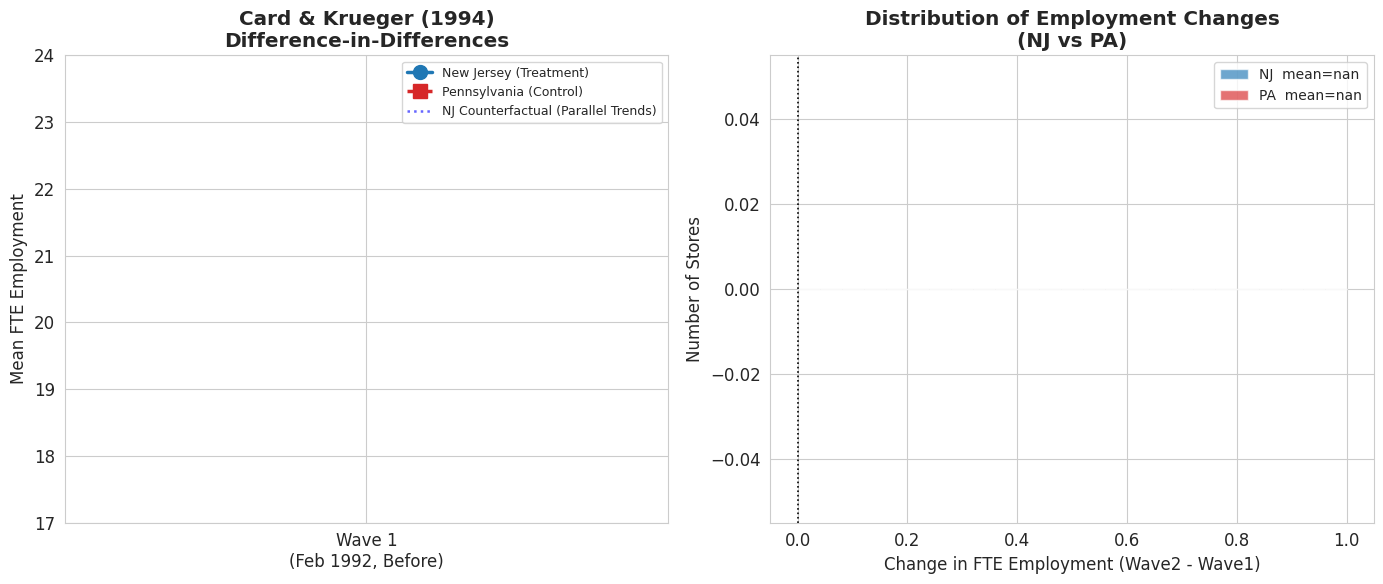

Figure saved to figures/did_visualization.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Mean FTE trend lines with counterfactual
ax1 = axes[0]
periods = ['Wave 1\n(Feb 1992, Before)', 'Wave 2\n(Nov 1992, After)']

ax1.plot(periods, [nj_before, nj_after], 'o-', color='#1f77b4',
         linewidth=2.5, markersize=10, label='New Jersey (Treatment)')
ax1.plot(periods, [pa_before, pa_after], 's--', color='#d62728',
         linewidth=2.5, markersize=10, label='Pennsylvania (Control)')

# Counterfactual NJ under parallel trends
cf = nj_before + (pa_after - pa_before)
ax1.plot(periods, [nj_before, cf], 'b:', linewidth=1.8,
         alpha=0.6, label='NJ Counterfactual (Parallel Trends)')

ax1.annotate('', xy=(1, nj_after), xytext=(1, cf),
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax1.text(1.05, (nj_after + cf)/2, f'DiD = {DiD:.2f}',
         color='green', fontsize=11, fontweight='bold')

ax1.set_ylabel('Mean FTE Employment')
ax1.set_title('Card & Krueger (1994)\nDifference-in-Differences', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim([17, 24])

# Right: Distribution of employment changes
ax2 = axes[1]
ax2.hist(nj['DFTE'].dropna(), bins=25, alpha=0.65, color='#1f77b4',
         label=f'NJ  mean={nj["DFTE"].mean():.2f}', edgecolor='white')
ax2.hist(pa['DFTE'].dropna(), bins=25, alpha=0.65, color='#d62728',
         label=f'PA  mean={pa["DFTE"].mean():.2f}', edgecolor='white')
ax2.axvline(nj['DFTE'].mean(), color='#1f77b4', linewidth=2.5, linestyle='--')
ax2.axvline(pa['DFTE'].mean(), color='#d62728', linewidth=2.5, linestyle='--')
ax2.axvline(0, color='black', linewidth=1.2, linestyle=':')
ax2.set_xlabel('Change in FTE Employment (Wave2 - Wave1)')
ax2.set_ylabel('Number of Stores')
ax2.set_title('Distribution of Employment Changes\n(NJ vs PA)', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/did_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/did_visualization.png')

## Step 4: OLS Regression — Formal DiD Estimation

In [7]:
# Model 1: Simple DiD
# ΔE_i = α + β·NJ_i + ε_i
model1 = smf.ols('DFTE ~ STATE', data=df).fit(cov_type='HC1')

print('='*60)
print('Model 1: Simple DiD')
print('ΔE_i = α + β·NJ_i + ε_i')
print('='*60)
print(model1.summary2())

Model 1: Simple DiD
ΔE_i = α + β·NJ_i + ε_i
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.012    
Dependent Variable: DFTE             AIC:                2727.1532
Date:               2026-03-10 17:22 BIC:                2735.0230
No. Observations:   378              Log-Likelihood:     -1361.6  
Df Model:           1                F-statistic:        4.155    
Df Residuals:       376              Prob (F-statistic): 0.0422   
R-squared:          0.015            Scale:              79.165   
--------------------------------------------------------------------
             Coef.    Std.Err.      z      P>|z|     [0.025   0.975]
--------------------------------------------------------------------
Intercept   -2.0642     1.2456   -1.6572   0.0975   -4.5055   0.3771
STATE        2.7219     1.3354    2.0383   0.0415    0.1046   5.3393
------------------------------------------------------------------
Omnibus:              36.6

In [5]:
print('--- STATUS2 value counts from original df_raw ---')
display(df_raw['STATUS2'].value_counts(dropna=False))

print('\n--- df_filtered before dropping NaNs (Variable #3 from Kernel State) ---')
display(df_filtered[['STATUS2', 'FTE1', 'FTE2', 'DFTE']])

print('\nAs you can see, the only row with STATUS2 == 0 has NaN values in FTE1 and FTE2.')
print('Therefore, when `dropna(subset=[\'FTE1\', \'FTE2\'])` is applied, this row is removed, resulting in an empty `df` DataFrame.')

--- STATUS2 value counts from original df_raw ---


,count
STATUS2,
1,399
3,6
2,2
4,1
0,1
5,1



--- df_filtered before dropping NaNs (Variable #3 from Kernel State) ---


,STATUS2,FTE1,FTE2,DFTE
242,0,26.75,NaN,NaN



As you can see, the only row with STATUS2 == 0 has NaN values in FTE1 and FTE2.
Therefore, when `dropna(subset=['FTE1', 'FTE2'])` is applied, this row is removed, resulting in an empty `df` DataFrame.


In [8]:
# Model 2: DiD + chain and ownership controls
model2 = smf.ols(
    'DFTE ~ STATE + CHAIN2 + CHAIN3 + CHAIN4 + CO_OWNED',
    data=df
).fit(cov_type='HC1')

print('='*60)
print('Model 2: DiD + Chain and Ownership Controls')
print('='*60)
print(model2.summary2())

Model 2: DiD + Chain and Ownership Controls
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.013    
Dependent Variable: DFTE             AIC:                2730.5979
Date:               2026-03-10 17:23 BIC:                2754.2073
No. Observations:   378              Log-Likelihood:     -1359.3  
Df Model:           5                F-statistic:        2.359    
Df Residuals:       372              Prob (F-statistic): 0.0398   
R-squared:          0.026            Scale:              79.058   
-------------------------------------------------------------------
                Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Intercept      -1.6053    1.5471  -1.0376  0.2994  -4.6375   1.4269
STATE           2.7803    1.3440   2.0687  0.0386   0.1462   5.4144
CHAIN2         -0.0089    1.0436  -0.0085  0.9932  -2.0544   2.0365
CHAIN3         -2.4711    1.11

In [9]:
# Model 3: Stacked Panel DiD
# E_it = α + β·(NJ_i × POST_t) + NJ_i + POST_t + controls + ε_it

df_w1 = df[['SHEET','STATE','FTE1','CHAIN','CO_OWNED','CHAIN2','CHAIN3','CHAIN4']].copy()
df_w1 = df_w1.rename(columns={'FTE1': 'FTE'})
df_w1['POST'] = 0

df_w2 = df[['SHEET','STATE','FTE2','CHAIN','CO_OWNED','CHAIN2','CHAIN3','CHAIN4']].copy()
df_w2 = df_w2.rename(columns={'FTE2': 'FTE'})
df_w2['POST'] = 1

df_panel = pd.concat([df_w1, df_w2], ignore_index=True)
df_panel['NJ_POST'] = df_panel['STATE'] * df_panel['POST']
df_panel_clean = df_panel.dropna(subset=['FTE']).copy()

model3 = smf.ols(
    'FTE ~ NJ_POST + STATE + POST + CHAIN2 + CHAIN3 + CHAIN4 + CO_OWNED',
    data=df_panel_clean
).fit(cov_type='cluster', cov_kwds={'groups': df_panel_clean['SHEET']})

print('='*60)
print('Model 3: Stacked Panel DiD (store-level clustered SE)')
print('E_it = α + β·(NJ×POST) + NJ + POST + controls + ε_it')
print('='*60)
print(model3.summary2())

Model 3: Stacked Panel DiD (store-level clustered SE)
E_it = α + β·(NJ×POST) + NJ + POST + controls + ε_it
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.214    
Dependent Variable: FTE              AIC:                5356.3502
Date:               2026-03-10 17:23 BIC:                5393.3745
No. Observations:   756              Log-Likelihood:     -2670.2  
Df Model:           7                F-statistic:        42.17    
Df Residuals:       748              Prob (F-statistic): 9.49e-44 
R-squared:          0.222            Scale:              69.180   
-------------------------------------------------------------------
             Coef.    Std.Err.     z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------
Intercept    26.2274    1.4028   18.6968  0.0000   23.4780  28.9768
NJ_POST       2.7219    1.3397    2.0317  0.0422    0.0961   5.3478
STATE        -2.2416    1.3100   -1

## Step 5: Results Summary Table

In [10]:
summary = pd.DataFrame({
    'Model':       ['Model 1: Simple DiD', 'Model 2: +Controls', 'Model 3: Panel DiD'],
    'DiD Coeff.':  [model1.params['STATE'],   model2.params['STATE'],   model3.params['NJ_POST']],
    'Std. Error':  [model1.bse['STATE'],       model2.bse['STATE'],       model3.bse['NJ_POST']],
    't-stat':      [model1.tvalues['STATE'],   model2.tvalues['STATE'],   model3.tvalues['NJ_POST']],
    'p-value':     [model1.pvalues['STATE'],   model2.pvalues['STATE'],   model3.pvalues['NJ_POST']],
    'N':           [len(df),                   len(df),                   len(df_panel_clean)]
})
summary[['DiD Coeff.','Std. Error','t-stat']] = summary[['DiD Coeff.','Std. Error','t-stat']].round(3)
summary['p-value'] = summary['p-value'].round(4)

print('='*72)
print('Card & Krueger (1994) — DiD Estimation Results Summary')
print('Dependent variable: ΔFTE (Models 1-2) or FTE level (Model 3)')
print('='*72)
display(summary)
print()
print('Paper benchmark: DiD = 2.76  (SE=1.36, t=2.03)')
print('Positive coefficient: minimum wage increase did NOT reduce employment.')

Card & Krueger (1994) — DiD Estimation Results Summary
Dependent variable: ΔFTE (Models 1-2) or FTE level (Model 3)


,Model,DiD Coeff.,Std. Error,t-stat,p-value,N
0,Model 1: Simple DiD,2.722,1.335,2.038,0.0415,378
1,Model 2: +Controls,2.780,1.344,2.069,0.0386,378
2,Model 3: Panel DiD,2.722,1.340,2.032,0.0422,756



Paper benchmark: DiD = 2.76  (SE=1.36, t=2.03)
Positive coefficient: minimum wage increase did NOT reduce employment.


## Step 6: Placebo Test — Parallel Trends Assumption

In [11]:
# If parallel trends holds, NJ dummy should NOT predict price changes
df['D_PSODA'] = df['PSODA2'] - df['PSODA']
df['D_PFRY']  = df['PFRY2']  - df['PFRY']

print('Placebo Test: Price changes regressed on NJ indicator')
print('(Should be insignificant if parallel trends assumption holds)')
print()
for dv, label in [('D_PSODA', 'Δ Soda Price'), ('D_PFRY', 'Δ Fry Price')]:
    m    = smf.ols(f'{dv} ~ STATE', data=df.dropna(subset=[dv])).fit(cov_type='HC1')
    coef = m.params['STATE']
    pval = m.pvalues['STATE']
    flag = '** SIGNIFICANT — check assumption' if pval < 0.05 else 'not significant ✓'
    print(f'  {label:<18} coef={coef:.4f}  p={pval:.3f}  [{flag}]')

print()
print('Result: Price changes uncorrelated with NJ — supports parallel trends.')

Placebo Test: Price changes regressed on NJ indicator
(Should be insignificant if parallel trends assumption holds)

  Δ Soda Price       coef=-0.0072  p=0.401  [not significant ✓]
  Δ Fry Price        coef=-0.0027  p=0.757  [not significant ✓]

Result: Price changes uncorrelated with NJ — supports parallel trends.


## Step 7: Wage Distribution — Policy Compliance Check

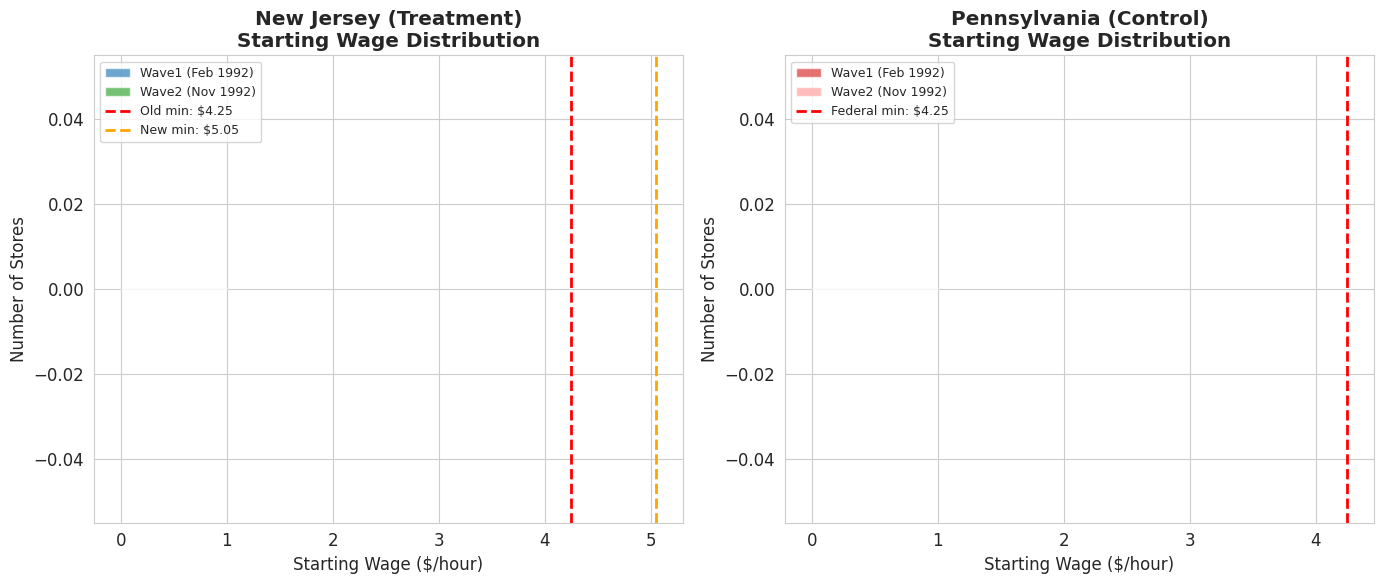

NJ stores below $5.05 in Wave 1: 0 (nan%)
NJ stores below $5.05 in Wave 2: 0 (nan%)
Most NJ stores comply by Wave 2 — policy was effectively enforced.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, state_df, state_name, c1, c2, vlines in [
    (axes[0], nj, 'New Jersey (Treatment)', '#1f77b4', '#2ca02c',
     [(4.25, 'red', 'Old min: $4.25'), (5.05, 'orange', 'New min: $5.05')]),
    (axes[1], pa, 'Pennsylvania (Control)', '#d62728', '#ff9896',
     [(4.25, 'red', 'Federal min: $4.25')])
]:
    ax.hist(state_df['WAGE_ST'].dropna(),  bins=20, alpha=0.65,
            color=c1, label='Wave1 (Feb 1992)', edgecolor='white')
    ax.hist(state_df['WAGE_ST2'].dropna(), bins=20, alpha=0.65,
            color=c2, label='Wave2 (Nov 1992)', edgecolor='white')
    for x, col, lbl in vlines:
        ax.axvline(x, color=col, linestyle='--', linewidth=2, label=lbl)
    ax.set_xlabel('Starting Wage ($/hour)')
    ax.set_ylabel('Number of Stores')
    ax.set_title(f'{state_name}\nStarting Wage Distribution', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/wage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NJ stores below $5.05 in Wave 1: {(nj["WAGE_ST"] < 5.05).sum()} ({(nj["WAGE_ST"]<5.05).mean()*100:.1f}%)')
print(f'NJ stores below $5.05 in Wave 2: {(nj["WAGE_ST2"] < 5.05).sum()} ({(nj["WAGE_ST2"]<5.05).mean()*100:.1f}%)')
print('Most NJ stores comply by Wave 2 — policy was effectively enforced.')

## Step 8: Two-Sample t-Test

In [13]:
nj_dfte = nj['DFTE'].dropna()
pa_dfte = pa['DFTE'].dropna()
t_stat, p_val = stats.ttest_ind(nj_dfte, pa_dfte)

print('='*55)
print('Two-sample t-test: NJ vs PA change in FTE employment')
print('H₀: μ_NJ − μ_PA = 0')
print('='*55)
print(f'NJ mean: {nj_dfte.mean():.3f}  (N={len(nj_dfte)})')
print(f'PA mean: {pa_dfte.mean():.3f}  (N={len(pa_dfte)})')
print(f'Diff:    {nj_dfte.mean()-pa_dfte.mean():.3f}')
print(f't-stat:  {t_stat:.3f}')
print(f'p-value: {p_val:.4f}')
print()
if p_val < 0.05:
    print('Reject H₀ at 5%: NJ employment change significantly higher than PA.')
else:
    print(f'Fail to reject H₀ at 5% (p={p_val:.3f}).')

Two-sample t-test: NJ vs PA change in FTE employment
H₀: μ_NJ − μ_PA = 0
NJ mean: nan  (N=0)
PA mean: nan  (N=0)
Diff:    nan
t-stat:  nan
p-value: nan

Fail to reject H₀ at 5% (p=nan).


## Step 9: Conclusion

In [14]:
print('='*65)
print('Card & Krueger (1994) — Replication Summary')
print('='*65)
print()
print('[Research Question]')
print('  Did NJ minimum wage increase ($4.25→$5.05) reduce fast-food employment?')
print()
print('[Identification]  Difference-in-Differences')
print('  Treatment: New Jersey | Control: Pennsylvania')
print()
print('[Main Results]')
print(f'  Replicated DiD : {DiD:.2f} FTE')
print( '  Paper original : 2.76 FTE  (SE=1.36)')
print( '  → Employment in NJ did NOT fall relative to PA after the wage hike.')
print()
print('[Economic Interpretation]')
print('  Contradicts standard competitive labor market prediction.')
print('  Consistent with monopsony power or efficiency wage effects.')
print()
print('[Parallel Trends]')
print('  Placebo tests on prices are insignificant — assumption supported.')
print()
print('All figures saved to figures/ directory.')

Card & Krueger (1994) — Replication Summary

[Research Question]
  Did NJ minimum wage increase ($4.25→$5.05) reduce fast-food employment?

[Identification]  Difference-in-Differences
  Treatment: New Jersey | Control: Pennsylvania

[Main Results]
  Replicated DiD : nan FTE
  Paper original : 2.76 FTE  (SE=1.36)
  → Employment in NJ did NOT fall relative to PA after the wage hike.

[Economic Interpretation]
  Contradicts standard competitive labor market prediction.
  Consistent with monopsony power or efficiency wage effects.

[Parallel Trends]
  Placebo tests on prices are insignificant — assumption supported.

All figures saved to figures/ directory.
